### SIMULATION SCENARIO B
___

Cluster labels: 
* 0 – Core Frontline Operations Staff (E&I)
* 1 – Specialized Technical Field Experts (E&I)
* 2 – Advanced Governance & Support Specialists
* 3 – Essential Infrastructure Field Crew (E&I)
* 4 – Strategic Business & Real Estate Leaders
* 5 – Governance & Support 

Overview of scenario types:
* Scenario A – Intended Baseline
* Scenario B – Periodic Quota Continuation
* Scenario C – Extended Retirement Age
* Scenario D – Extended Retirement + Periodic Quota
* Scenario E – Accelerated Outsourcing
* Scenario F – Complete No Quota

Overview of the selected KPI charts:
* E&I Scores (Tier 1 clusters)
* SS&G Scores (All clusters)
* Workforce headcount
* Future Readiness Index
* Annual Hires vs Retirees
* Cluster headcount – Core policy narrative
* Senior-to-Junior ratio Tier 1 – Core mechanism
* Support cluster depletion – Contextual policy contrast

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['legend.facecolor']  = 'white'
plt.rcParams['legend.edgecolor']  = '0.8'

___
SCENARIO B

In [3]:
#LOAD THE COMBINED DATASET
path = 'SCENARIOAF.csv'
master = pd.read_csv(path)

In [4]:
#LOAD SCENARIO B
df = master[master['scenarioID'] == 1].copy()
print(df.info())
print(df.isnull().sum())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 34 to 67
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   scenarioID          34 non-null     int64  
 1   year                34 non-null     float64
 2   avgBM_0             34 non-null     float64
 3   avgBM_1             34 non-null     float64
 4   avgBM_2             34 non-null     float64
 5   avgBM_3             34 non-null     float64
 6   avgBM_4             34 non-null     float64
 7   avgBM_5             34 non-null     float64
 8   avgTD_0             34 non-null     float64
 9   avgTD_1             34 non-null     float64
 10  avgTD_2             34 non-null     float64
 11  avgTD_3             34 non-null     float64
 12  avgTD_4             34 non-null     float64
 13  avgTD_5             34 non-null     float64
 14  avgEI_0             34 non-null     float64
 15  avgEI_1             34 non-null     float64
 16  avgEI_2             

,scenarioID,year,avgBM_0,avgBM_1,avgBM_2,avgBM_3,avgBM_4,avgBM_5,avgTD_0,avgTD_1,...,count_3,count_4,count_5,gMentor0,gMentor1,gMentor3,annualRetireeCount,annualHireCount,crisisState,scenarioLabel
34,1,2027.01,3.832719,4.689530,4.821323,4.373173,4.804760,4.668701,3.770341,4.755928,...,3652,63,402,0.385708,0.646707,0.521033,0,0,0,B - Periodic Quota Continuation
35,1,2028.01,3.735628,4.243377,4.854998,4.224430,4.843901,4.693387,3.679271,4.431952,...,4166,62,389,0.327427,0.396226,0.413641,303,0,0,B - Periodic Quota Continuation
36,1,2029.01,3.730157,4.177528,4.870442,4.208664,4.880763,4.716573,3.672085,4.394568,...,4275,62,376,0.310901,0.341751,0.381260,293,15,0,B - Periodic Quota Continuation
37,1,2030.01,3.736632,4.140246,4.887625,4.211422,4.907757,4.724823,3.675516,4.380228,...,4315,59,367,0.297404,0.298003,0.360340,324,15,0,B - Periodic Quota Continuation
38,1,2031.01,3.736448,4.104091,4.913585,4.208139,4.930800,4.718722,3.673288,4.365299,...,4427,58,356,0.281347,0.269553,0.334640,262,16,0,B - Periodic Quota Continuation


In [5]:
# STATE MARKERS
def state_spells(df, state):
    yrs = sorted(df.loc[df['crisisState'] == state, 'year'].tolist())
    out, start, prev = [], None, None
    for y in yrs:
        if start is None:
            start = prev = y
        elif y == prev + 1:
            prev = y
        else:
            out.append((start, prev)); start = prev = y
    if start is not None:
        out.append((start, prev))
    return out

def mark_states(ax, df):
    for i, (a, b) in enumerate(state_spells(df, 1)):
        ax.axvspan(a - 0.5, b + 0.5, color='#F39C12', alpha=0.15, zorder=0,
                   label='WARNING' if i == 0 else None)
    for i, (a, b) in enumerate(state_spells(df, 2)):
        ax.axvspan(a - 0.5, b + 0.5, color='#C0392B', alpha=0.15, zorder=0,
                   label='CRISIS' if i == 0 else None)

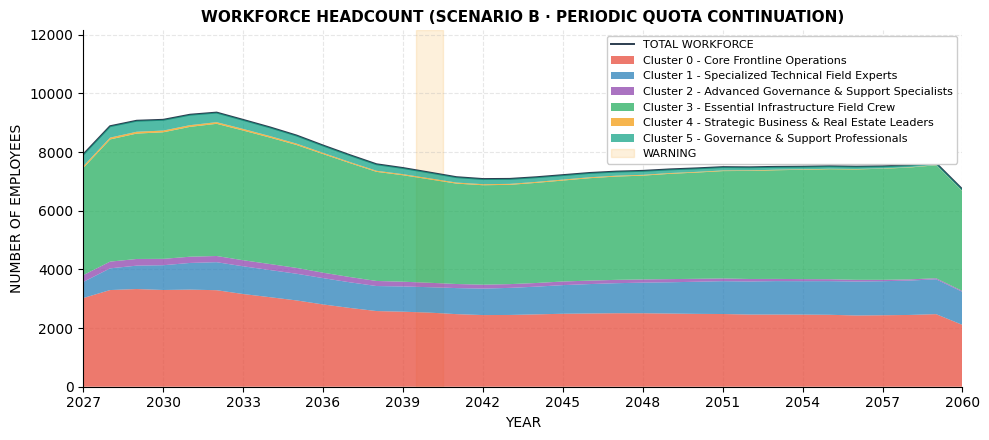

In [7]:
# PLOT 1 — WORKFORCE HEADCOUNT · SCENARIO B
df = master[master['scenarioID'] == 1].copy()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(df['year'], df['count_0'] + df['count_1'] + df['count_2'] + df['count_3'] + df['count_4'] + df['count_5'], color='#2C3E50', linewidth=1.4, label='TOTAL WORKFORCE')
ax.stackplot(df['year'],
             df['count_0'], df['count_1'], df['count_2'],
             df['count_3'], df['count_4'], df['count_5'],
             labels=[
                 'Cluster 0 - Core Frontline Operations',
                 'Cluster 1 - Specialized Technical Field Experts',
                 'Cluster 2 - Advanced Governance & Support Specialists',
                 'Cluster 3 - Essential Infrastructure Field Crew',
                 'Cluster 4 - Strategic Business & Real Estate Leaders',
                 'Cluster 5 - Governance & Support Professionals',
             ],
             colors=['#E74C3C','#2980B9','#8E44AD','#27AE60','#F39C12','#17A589'],
             alpha=0.75)
ax.set_ylim(0, df[[f'count_{i}' for i in range(6)]].sum(axis=1).max() * 1.30)
mark_states(ax, df)
for coll in ax.collections:
    coll.set_zorder(2)
ax.set_title('WORKFORCE HEADCOUNT (SCENARIO B · PERIODIC QUOTA CONTINUATION)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2027, 2060)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

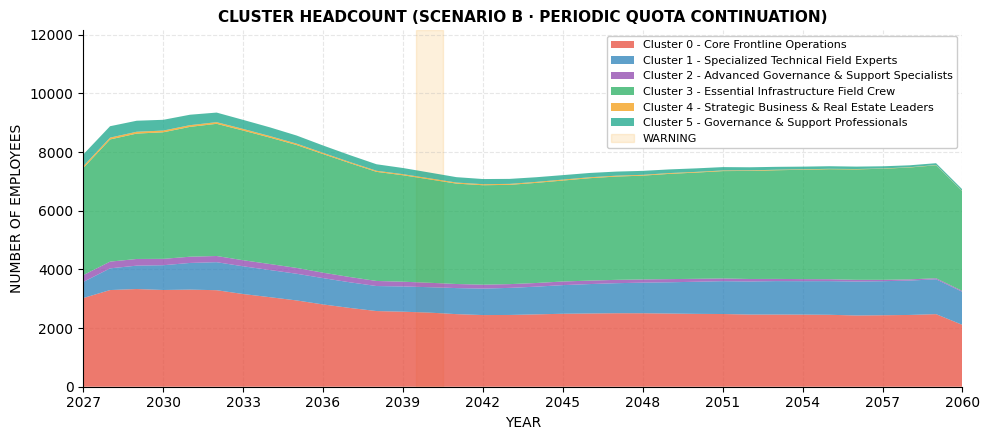

In [8]:
# PLOT 2 — CLUSTER HEADCOUNT · SCENARIO B
df = master[master['scenarioID'] == 1].copy()
COLOURS = {
    'count_0': '#E74C3C',  # Cluster 0 – Core Frontline Operations Staff
    'count_1': '#2980B9',  # Cluster 1 – Specialized Technical Field Experts
    'count_2': '#8E44AD',  # Cluster 2 – Advanced Governance & Support Specialists
    'count_3': '#27AE60',  # Cluster 3 – Essential Infrastructure Field Crew
    'count_4': '#F39C12',  # Cluster 4 – Strategic Business & Real Estate Leaders
    'count_5': '#17A589',  # Cluster 5 – Governance & Support Professionals
}
LABELS = {
    'count_0': 'Cluster 0 - Core Frontline Operations',
    'count_1': 'Cluster 1 - Specialized Technical Field Experts',
    'count_2': 'Cluster 2 - Advanced Governance & Support Specialists',
    'count_3': 'Cluster 3 - Essential Infrastructure Field Crew',
    'count_4': 'Cluster 4 - Strategic Business & Real Estate Leaders',
    'count_5': 'Cluster 5 - Governance & Support Professionals',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.stackplot(df['year'],
             df['count_0'], df['count_1'], df['count_2'],
             df['count_3'], df['count_4'], df['count_5'],
             labels=list(LABELS.values()),
             colors=list(COLOURS.values()),
             alpha=0.75)
ax.set_ylim(0, df[[f'count_{i}' for i in range(6)]].sum(axis=1).max() * 1.30)
mark_states(ax, df)
for coll in ax.collections:
    coll.set_zorder(2)
ax.set_title('CLUSTER HEADCOUNT (SCENARIO B · PERIODIC QUOTA CONTINUATION)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2027, 2060)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

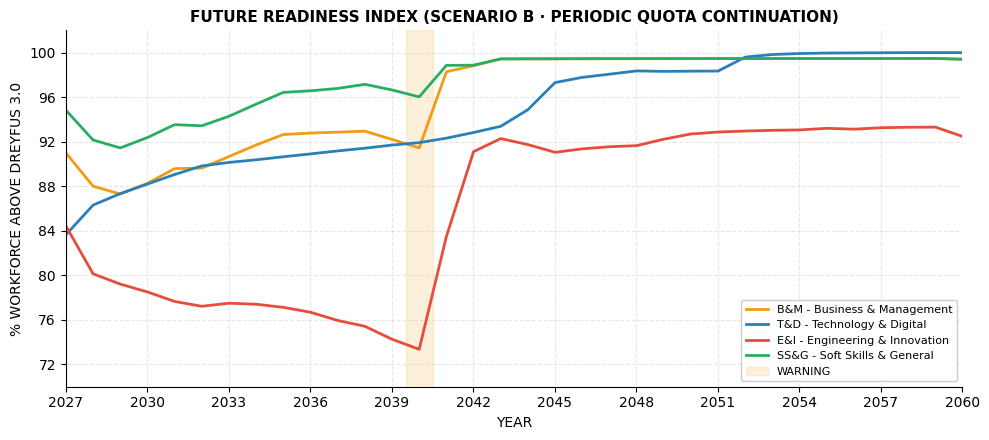

In [9]:
# PLOT 3 — FUTURE READINESS INDEX · SCENARIO B
df = master[master['scenarioID'] == 1].copy()
COLOURS = {
    'friBM':  '#F39C12',  # Business & Management
    'friTD':  '#2980B9',  # Technology & Digital
    'friEI':  '#E74C3C',  # Engineering & Innovation
    'friSSG': '#27AE60',  # Soft Skills & General
}
LABELS = {
    'friBM':  'B&M - Business & Management',
    'friTD':  'T&D - Technology & Digital',
    'friEI':  'E&I - Engineering & Innovation',
    'friSSG': 'SS&G - Soft Skills & General',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col] * 100, color=colour, linewidth=2, label=LABELS[col])
mark_states(ax, df)
ax.set_title('FUTURE READINESS INDEX (SCENARIO B · PERIODIC QUOTA CONTINUATION)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('% WORKFORCE ABOVE DREYFUS 3.0')
ax.set_xlim(2027, 2060)
ax.set_ylim(70, 102)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

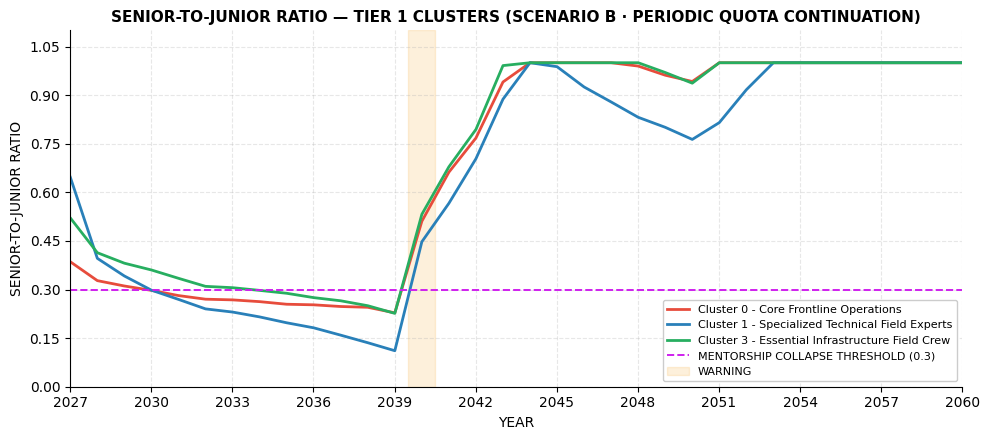

In [10]:
# PLOT 4 — SENIOR-TO-JUNIOR RATIO · TIER 1 CLUSTERS · SCENARIO B
df = master[master['scenarioID'] == 1].copy()
COLOURS = {
    'gMentor0': '#E74C3C',  # Cluster 0 – Core Frontline Operations Staff
    'gMentor1': '#2980B9',  # Cluster 1 – Specialized Technical Field Experts
    'gMentor3': '#27AE60',  # Cluster 3 – Essential Infrastructure Field Crew
}
LABELS = {
    'gMentor0': 'Cluster 0 - Core Frontline Operations',
    'gMentor1': 'Cluster 1 - Specialized Technical Field Experts',
    'gMentor3': 'Cluster 3 - Essential Infrastructure Field Crew',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, label=LABELS[col])
ax.axhline(0.3, color='#CF20EE', linewidth=1.4, linestyle='--', label='MENTORSHIP COLLAPSE THRESHOLD (0.3)')
mark_states(ax, df)
ax.set_title('SENIOR-TO-JUNIOR RATIO — TIER 1 CLUSTERS (SCENARIO B · PERIODIC QUOTA CONTINUATION)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('SENIOR-TO-JUNIOR RATIO')
ax.set_xlim(2027, 2060)
ax.set_ylim(0.0, 1.1)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

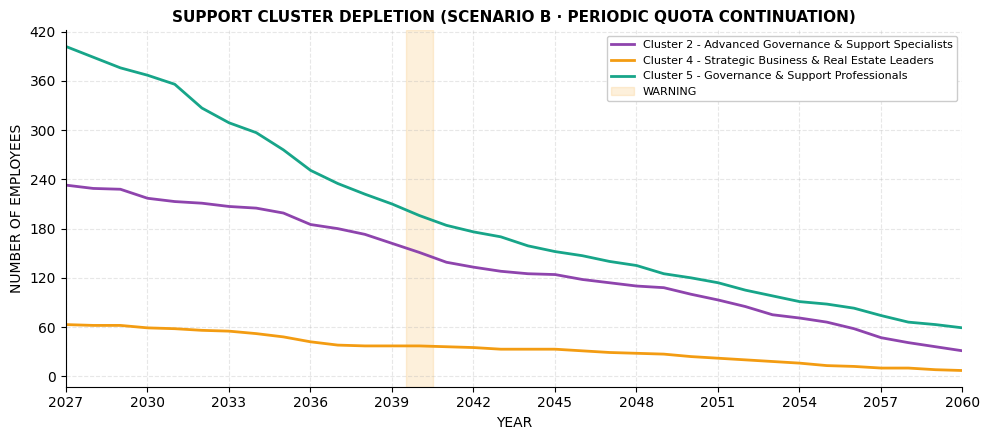

In [11]:
# PLOT 5 — SUPPORT CLUSTER DEPLETION · SCENARIO B
df = master[master['scenarioID'] == 1].copy()
COLOURS = {
    'count_2': '#8E44AD',  # Cluster 2 – Advanced Governance & Support Specialists
    'count_4': '#F39C12',  # Cluster 4 – Strategic Business & Real Estate Leaders
    'count_5': '#17A589',  # Cluster 5 – Governance & Support Professionals
}
LABELS = {
    'count_2': 'Cluster 2 - Advanced Governance & Support Specialists',
    'count_4': 'Cluster 4 - Strategic Business & Real Estate Leaders',
    'count_5': 'Cluster 5 - Governance & Support Professionals',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, label=LABELS[col])
mark_states(ax, df)
ax.set_title('SUPPORT CLUSTER DEPLETION (SCENARIO B · PERIODIC QUOTA CONTINUATION)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2027, 2060)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

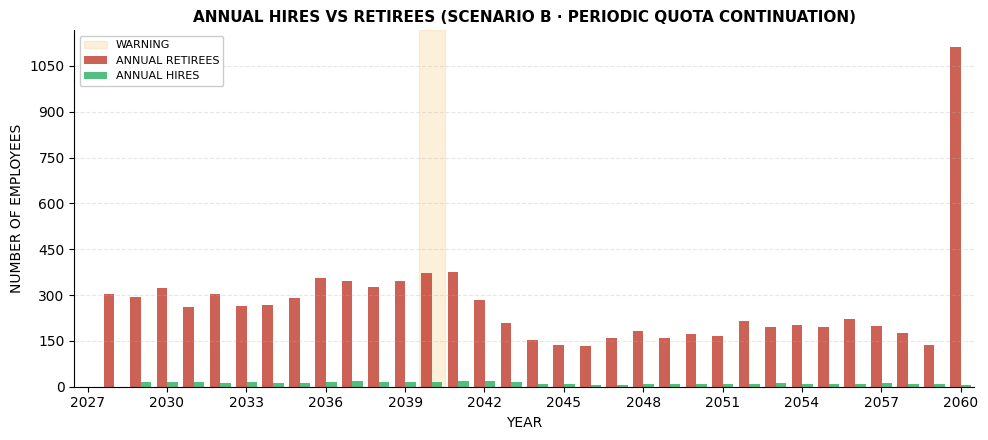

In [12]:
# PLOT 6 — ANNUAL HIRES VS RETIREES · SCENARIO B
df = master[master['scenarioID'] == 1].copy()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(df['year'] - 0.2, df['annualRetireeCount'], width=0.4, color='#C0392B', alpha=0.8, label='ANNUAL RETIREES')
ax.bar(df['year'] + 0.2, df['annualHireCount'], width=0.4, color='#27AE60', alpha=0.8, label='ANNUAL HIRES')
mark_states(ax, df)
ax.set_title('ANNUAL HIRES VS RETIREES (SCENARIO B · PERIODIC QUOTA CONTINUATION)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2026.5, 2060.5)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

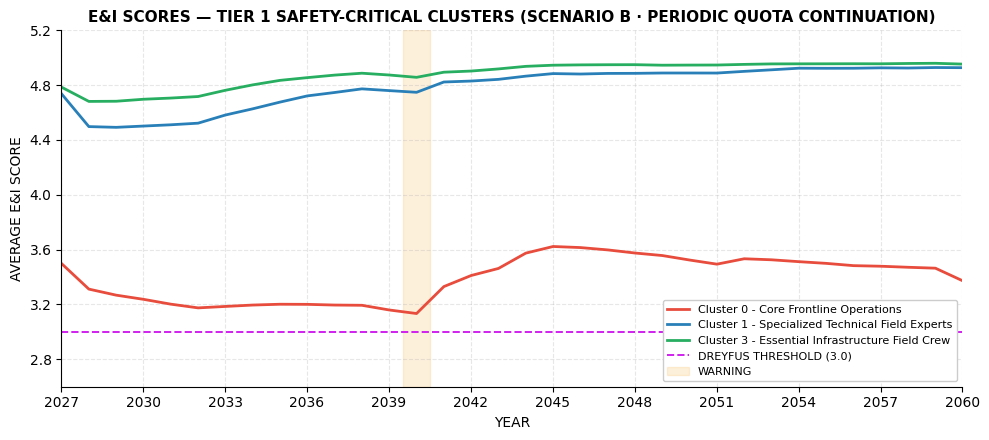

In [13]:
# PLOT 7 — E&I SCORES · TIER 1 CLUSTERS · SCENARIO B
df = master[master['scenarioID'] == 1].copy()
DREYFUS = 3.0
COLOURS = {
    'avgEI_0': '#E74C3C',  # Cluster 0 – Core Frontline Operations Staff
    'avgEI_1': '#2980B9',  # Cluster 1 – Specialized Technical Field Experts
    'avgEI_3': '#27AE60',  # Cluster 3 – Essential Infrastructure Field Crew
}
LABELS = {
    'avgEI_0': 'Cluster 0 - Core Frontline Operations',
    'avgEI_1': 'Cluster 1 - Specialized Technical Field Experts',
    'avgEI_3': 'Cluster 3 - Essential Infrastructure Field Crew',
}

fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, label=LABELS[col])
ax.axhline(DREYFUS, color="#CF20EE", linewidth=1.4, linestyle='--', label='DREYFUS THRESHOLD (3.0)')
mark_states(ax, df)
ax.set_title('E&I SCORES — TIER 1 SAFETY-CRITICAL CLUSTERS (SCENARIO B · PERIODIC QUOTA CONTINUATION)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('AVERAGE E&I SCORE')
ax.set_xlim(2027, 2060)
ax.set_ylim(2.6, 5.2)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

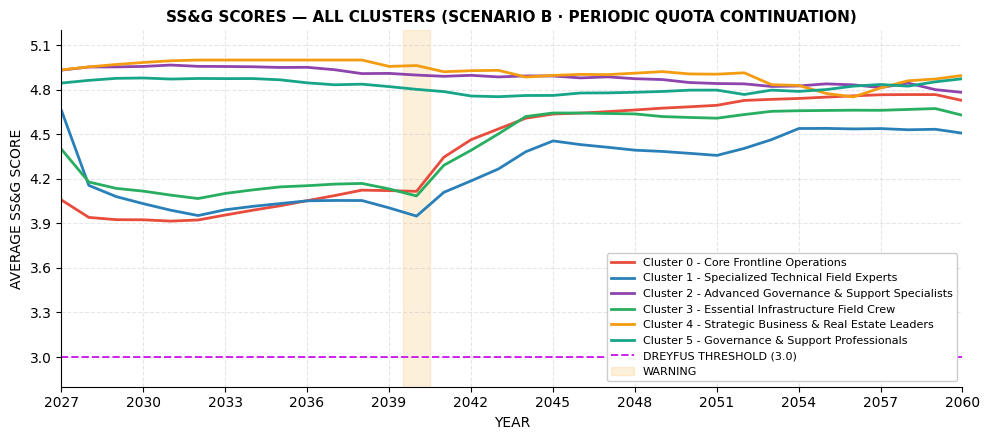

In [14]:
# PLOT 8 — SS&G SCORES · ALL CLUSTERS · SCENARIO B
df = master[master['scenarioID'] == 1].copy()
DREYFUS = 3.0
COLOURS = {
    'avgSSG_0': '#E74C3C',  # Cluster 0 – Core Frontline Operations Staff
    'avgSSG_1': '#2980B9',  # Cluster 1 – Specialized Technical Field Experts
    'avgSSG_2': '#8E44AD',  # Cluster 2 – Advanced Governance & Support Specialists
    'avgSSG_3': '#27AE60',  # Cluster 3 – Essential Infrastructure Field Crew
    'avgSSG_4': '#F39C12',  # Cluster 4 – Strategic Business & Real Estate Leaders
    'avgSSG_5': '#17A589',  # Cluster 5 – Governance & Support Professionals
}
LABELS = {
    'avgSSG_0': 'Cluster 0 - Core Frontline Operations',
    'avgSSG_1': 'Cluster 1 - Specialized Technical Field Experts',
    'avgSSG_2': 'Cluster 2 - Advanced Governance & Support Specialists',
    'avgSSG_3': 'Cluster 3 - Essential Infrastructure Field Crew',
    'avgSSG_4': 'Cluster 4 - Strategic Business & Real Estate Leaders',
    'avgSSG_5': 'Cluster 5 - Governance & Support Professionals',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, label=LABELS[col])
ax.axhline(DREYFUS, color='#CF20EE', linewidth=1.4, linestyle='--', label='DREYFUS THRESHOLD (3.0)')
mark_states(ax, df)
ax.set_title('SS&G SCORES — ALL CLUSTERS (SCENARIO B · PERIODIC QUOTA CONTINUATION)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('AVERAGE SS&G SCORE')
ax.set_xlim(2027, 2060)
ax.set_ylim(2.8, 5.2)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right', )
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

___
**END**